In [1]:
from kaggle.api.kaggle_api_extended import KaggleApi

In [2]:
api = KaggleApi()
api.authenticate()

api.dataset_download_files(
    'rohanrao/formula-1-world-championship-1950-2020',
    path='./f1_datasets',
    unzip=True
)

Dataset URL: https://www.kaggle.com/datasets/rohanrao/formula-1-world-championship-1950-2020


In [3]:
import pandas as pd
import os
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

datasets = ['circuits', 'constructors', 'drivers', 'races', 'results']

dataframes = {}
for dataset in datasets:
    file_path = os.path.join('./f1_datasets', f'{dataset}.csv')
    dataframes[dataset] = pd.read_csv(file_path)

dataframes

{'circuits':     circuitId   circuitRef                                  name  \
 0           1  albert_park        Albert Park Grand Prix Circuit   
 1           2       sepang          Sepang International Circuit   
 2           3      bahrain         Bahrain International Circuit   
 3           4    catalunya        Circuit de Barcelona-Catalunya   
 4           5     istanbul                         Istanbul Park   
 ..        ...          ...                                   ...   
 72         75     portimao    Autódromo Internacional do Algarve   
 73         76      mugello  Autodromo Internazionale del Mugello   
 74         77       jeddah               Jeddah Corniche Circuit   
 75         78       losail          Losail International Circuit   
 76         79        miami         Miami International Autodrome   
 
         location       country       lat        lng  alt  \
 0      Melbourne     Australia -37.84970  144.96800   10   
 1   Kuala Lumpur      Malaysia   2.

In [4]:
dataframes['races'].columns, dataframes['results'].columns, dataframes['constructors'].columns, dataframes['circuits'].columns, dataframes['drivers'].columns

(Index(['raceId', 'year', 'round', 'circuitId', 'name', 'date', 'time', 'url',
        'fp1_date', 'fp1_time', 'fp2_date', 'fp2_time', 'fp3_date', 'fp3_time',
        'quali_date', 'quali_time', 'sprint_date', 'sprint_time'],
       dtype='object'),
 Index(['resultId', 'raceId', 'driverId', 'constructorId', 'number', 'grid',
        'position', 'positionText', 'positionOrder', 'points', 'laps', 'time',
        'milliseconds', 'fastestLap', 'rank', 'fastestLapTime',
        'fastestLapSpeed', 'statusId'],
       dtype='object'),
 Index(['constructorId', 'constructorRef', 'name', 'nationality', 'url'], dtype='object'),
 Index(['circuitId', 'circuitRef', 'name', 'location', 'country', 'lat', 'lng',
        'alt', 'url'],
       dtype='object'),
 Index(['driverId', 'driverRef', 'number', 'code', 'forename', 'surname', 'dob',
        'nationality', 'url'],
       dtype='object'))

In [5]:
dataframes['races'].drop(columns=['url', 'round', 'fp1_date', 'fp1_time', 'fp2_date', 'fp2_time', 'fp3_date', 'fp3_time',
        'quali_date', 'quali_time', 'sprint_date', 'sprint_time', 'time'], inplace=True)
dataframes['races'].rename(columns={'name': 'GP name'}, inplace=True)
dataframes['constructors'].drop(columns=['constructorRef', 'url'], inplace=True)
dataframes['constructors'].rename(columns={'name': 'team', 'nationality': 'team_home'}, inplace=True)
dataframes['drivers'].drop(columns=['forename', 'driverRef', 'code', 'number', 'url'], inplace=True)
dataframes['drivers'].rename(columns={'surname': 'driver', 'nationality': 'driver_home'}, inplace=True)
dataframes['results'].drop(columns=['positionText', 'points', 'laps', 'time', 'milliseconds', 'positionOrder', 'fastestLapTime',
                                    'fastestLapSpeed', 'rank', 'laps', 'time', 'number'], inplace=True)
dataframes['results'].rename(columns={'position': 'finish', 'grid': 'start'}, inplace=True)
dataframes['circuits'].drop(columns=['circuitRef', 'url', 'lat', 'lng', 'alt'], inplace=True)
dataframes['circuits'].rename(columns={'name': 'circuit name'}, inplace=True)

In [6]:
f1_data = dataframes['races'].merge(
    dataframes['results'], on='raceId', how='left'
    ).merge(
        dataframes['constructors'], on='constructorId', how='left'
    ).merge(
        dataframes['drivers'], on='driverId', how='left'
    ).merge(
        dataframes['circuits'], on='circuitId', how='left'
        )



In [7]:
f1_data = f1_data[f1_data['year'] >= 2018]
f1_data.shape

(2979, 20)

In [8]:
f1_data['date'] = pd.to_datetime(f1_data['date'])
f1_data['dob'] = pd.to_datetime(f1_data['dob'])

In [9]:
f1_data.columns

Index(['raceId', 'year', 'circuitId', 'GP name', 'date', 'resultId',
       'driverId', 'constructorId', 'start', 'finish', 'fastestLap',
       'statusId', 'team', 'team_home', 'driver', 'dob', 'driver_home',
       'circuit name', 'location', 'country'],
      dtype='object')

In [10]:
f1_data.drop(columns=['resultId', 'constructorId', 'fastestLap', 'driverId', 'circuitId', 'raceId'], inplace=True)
f1_data.shape

(2979, 14)

In [11]:
f1_data

,year,GP name,date,start,finish,statusId,team,team_home,driver,dob,driver_home,circuit name,location,country
23780,2018,Australian Grand Prix,2018-03-25,3,1,1,Ferrari,Italian,Vettel,1987-07-03,German,Albert Park Grand Prix Circuit,Melbourne,Australia
23781,2018,Australian Grand Prix,2018-03-25,1,2,1,Mercedes,German,Hamilton,1985-01-07,British,Albert Park Grand Prix Circuit,Melbourne,Australia
23782,2018,Australian Grand Prix,2018-03-25,2,3,1,Ferrari,Italian,Räikkönen,1979-10-17,Finnish,Albert Park Grand Prix Circuit,Melbourne,Australia
23783,2018,Australian Grand Prix,2018-03-25,8,4,1,Red Bull,Austrian,Ricciardo,1989-07-01,Australian,Albert Park Grand Prix Circuit,Melbourne,Australia
23784,2018,Australian Grand Prix,2018-03-25,10,5,1,McLaren,British,Alonso,1981-07-29,Spanish,Albert Park Grand Prix Circuit,Melbourne,Australia
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26754,2024,Abu Dhabi Grand Prix,2024-12-08,14,16,11,Haas F1 Team,American,Magnussen,1992-10-05,Danish,Yas Marina Circuit,Abu Dhabi,UAE
26755,2024,Abu Dhabi Grand Prix,2024-12-08,12,17,5,RB F1 Team,Italian,Lawson,2002-02-11,New Zealander,Yas Marina Circuit,Abu Dhabi,UAE
26756,2024,Abu Dhabi Grand Prix,2024-12-08,9,\N,130,Sauber,Swiss,Bottas,1989-08-28,Finnish,Yas Marina Circuit,Abu Dhabi,UAE
26757,2024,Abu Dhabi Grand Prix,2024-12-08,20,\N,5,Williams,British,Colapinto,2003-05-27,Argentinian,Yas Marina Circuit,Abu Dhabi,UAE


In [12]:
print(f1_data['team_home'].unique())
print(f1_data['driver_home'].unique())
print(f1_data['country'].unique())

['Italian' 'German' 'Austrian' 'British' 'French' 'Indian' 'Swiss'
 'American']
['German' 'British' 'Finnish' 'Australian' 'Spanish' 'Dutch' 'Belgian'
 'Mexican' 'French' 'Monegasque' 'Canadian' 'New Zealander' 'Danish'
 'Swedish' 'Russian' 'Thai' 'Italian' 'Polish' 'Brazilian' 'Japanese'
 'Chinese' 'American' 'Argentinian ']
['Australia' 'Bahrain' 'China' 'Azerbaijan' 'Spain' 'Monaco' 'Canada'
 'France' 'Austria' 'UK' 'Germany' 'Hungary' 'Belgium' 'Italy' 'Singapore'
 'Russia' 'Japan' 'USA' 'Mexico' 'Brazil' 'UAE' 'Portugal' 'Turkey'
 'Qatar' 'Netherlands' 'Saudi Arabia' 'United States']


In [13]:
def nationality(x):
    x = str(x).strip().lower()
    if x in ['austrian', 'austria']:
        return 'AUT'
    if x in ['australian', 'australia']:
        return 'AUS'
    if x in ['indian', 'india']:
        return 'IND'
    if x in ['indonesian', 'indonesia']:
        return 'INA'
    if x in ['uk', 'british', 'england', 'great britain']:
        return 'BRI'
    if x in ['usa', 'united states', 'american']:
        return 'AME'
    if x in ['fra', 'france', 'french']:
        return 'FRE'
    return x[:3].upper()

f1_data['driver_home'] = f1_data['driver_home'].apply(nationality)
f1_data['team_home'] = f1_data['team_home'].apply(nationality)
f1_data['country'] = f1_data['country'].apply(nationality)

f1_data['driver home'] = (f1_data['driver_home'] == f1_data['country']).astype(int)
f1_data['team home'] = (f1_data['team_home'] == f1_data['country']).astype(int)

In [14]:
print(f1_data['driver home'].unique())
print(f1_data['team home'].unique())
f1_data = f1_data.drop(columns=['driver_home', 'team_home'])
f1_data

[0 1]
[0 1]


,year,GP name,date,start,finish,statusId,team,driver,dob,circuit name,location,country,driver home,team home
23780,2018,Australian Grand Prix,2018-03-25,3,1,1,Ferrari,Vettel,1987-07-03,Albert Park Grand Prix Circuit,Melbourne,AUS,0,0
23781,2018,Australian Grand Prix,2018-03-25,1,2,1,Mercedes,Hamilton,1985-01-07,Albert Park Grand Prix Circuit,Melbourne,AUS,0,0
23782,2018,Australian Grand Prix,2018-03-25,2,3,1,Ferrari,Räikkönen,1979-10-17,Albert Park Grand Prix Circuit,Melbourne,AUS,0,0
23783,2018,Australian Grand Prix,2018-03-25,8,4,1,Red Bull,Ricciardo,1989-07-01,Albert Park Grand Prix Circuit,Melbourne,AUS,1,0
23784,2018,Australian Grand Prix,2018-03-25,10,5,1,McLaren,Alonso,1981-07-29,Albert Park Grand Prix Circuit,Melbourne,AUS,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26754,2024,Abu Dhabi Grand Prix,2024-12-08,14,16,11,Haas F1 Team,Magnussen,1992-10-05,Yas Marina Circuit,Abu Dhabi,UAE,0,0
26755,2024,Abu Dhabi Grand Prix,2024-12-08,12,17,5,RB F1 Team,Lawson,2002-02-11,Yas Marina Circuit,Abu Dhabi,UAE,0,0
26756,2024,Abu Dhabi Grand Prix,2024-12-08,9,\N,130,Sauber,Bottas,1989-08-28,Yas Marina Circuit,Abu Dhabi,UAE,0,0
26757,2024,Abu Dhabi Grand Prix,2024-12-08,20,\N,5,Williams,Colapinto,2003-05-27,Yas Marina Circuit,Abu Dhabi,UAE,0,0


In [15]:
f1_data = f1_data.reset_index(drop=True)
f1_data

,year,GP name,date,start,finish,statusId,team,driver,dob,circuit name,location,country,driver home,team home
0,2018,Australian Grand Prix,2018-03-25,3,1,1,Ferrari,Vettel,1987-07-03,Albert Park Grand Prix Circuit,Melbourne,AUS,0,0
1,2018,Australian Grand Prix,2018-03-25,1,2,1,Mercedes,Hamilton,1985-01-07,Albert Park Grand Prix Circuit,Melbourne,AUS,0,0
2,2018,Australian Grand Prix,2018-03-25,2,3,1,Ferrari,Räikkönen,1979-10-17,Albert Park Grand Prix Circuit,Melbourne,AUS,0,0
3,2018,Australian Grand Prix,2018-03-25,8,4,1,Red Bull,Ricciardo,1989-07-01,Albert Park Grand Prix Circuit,Melbourne,AUS,1,0
4,2018,Australian Grand Prix,2018-03-25,10,5,1,McLaren,Alonso,1981-07-29,Albert Park Grand Prix Circuit,Melbourne,AUS,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2974,2024,Abu Dhabi Grand Prix,2024-12-08,14,16,11,Haas F1 Team,Magnussen,1992-10-05,Yas Marina Circuit,Abu Dhabi,UAE,0,0
2975,2024,Abu Dhabi Grand Prix,2024-12-08,12,17,5,RB F1 Team,Lawson,2002-02-11,Yas Marina Circuit,Abu Dhabi,UAE,0,0
2976,2024,Abu Dhabi Grand Prix,2024-12-08,9,\N,130,Sauber,Bottas,1989-08-28,Yas Marina Circuit,Abu Dhabi,UAE,0,0
2977,2024,Abu Dhabi Grand Prix,2024-12-08,20,\N,5,Williams,Colapinto,2003-05-27,Yas Marina Circuit,Abu Dhabi,UAE,0,0


In [16]:
missing = f1_data[f1_data['dob'].isna()]
missing['driver'].unique()

array([], dtype=object)

In [17]:
season2025 = pd.read_csv('./f1_datasets/season2025.csv', index_col=0)

In [18]:
f1_data = pd.concat([f1_data, season2025])
f1_data.reset_index(drop=True)
f1_data

,year,GP name,date,start,finish,statusId,team,driver,dob,circuit name,location,country,driver home,team home
0,2018,Australian Grand Prix,2018-03-25 00:00:00,3,1,1,Ferrari,Vettel,1987-07-03 00:00:00,Albert Park Grand Prix Circuit,Melbourne,AUS,0,0
1,2018,Australian Grand Prix,2018-03-25 00:00:00,1,2,1,Mercedes,Hamilton,1985-01-07 00:00:00,Albert Park Grand Prix Circuit,Melbourne,AUS,0,0
2,2018,Australian Grand Prix,2018-03-25 00:00:00,2,3,1,Ferrari,Räikkönen,1979-10-17 00:00:00,Albert Park Grand Prix Circuit,Melbourne,AUS,0,0
3,2018,Australian Grand Prix,2018-03-25 00:00:00,8,4,1,Red Bull,Ricciardo,1989-07-01 00:00:00,Albert Park Grand Prix Circuit,Melbourne,AUS,1,0
4,2018,Australian Grand Prix,2018-03-25 00:00:00,10,5,1,McLaren,Alonso,1981-07-29 00:00:00,Albert Park Grand Prix Circuit,Melbourne,AUS,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
257,2025,Austrian Grand Prix,2025-06-29,12,17,3,Williams,Albon,1996-03-23,Red Bull Ring,Spielberg,AUT,0,0
258,2025,Austrian Grand Prix,2025-06-29,7,18,3,Red Bull,Verstappen,1972-03-04,Red Bull Ring,Spielberg,AUT,0,1
259,2025,Austrian Grand Prix,2025-06-29,7,18,3,Red Bull,Verstappen,1997-09-30,Red Bull Ring,Spielberg,AUT,0,1
260,2025,Austrian Grand Prix,2025-06-29,9,19,3,Mercedes,Antonelli,NaN,Red Bull Ring,Spielberg,AUT,0,0


In [19]:
f1_data['driver_dnf'] = f1_data['statusId'].apply(lambda x: 1 if x in [3,4,20,31,41,68,73,81,97,82,104,107,130,137] else 0)
f1_data['team_dnf'] = f1_data['statusId'].apply(lambda x: 1 if x not in [1, 3,4,20,31,41,68,73,81,97,82,104,107,130,137] else 0)

In [20]:
p = f1_data[(f1_data['finish']=='\\N') & (f1_data['driver_dnf']==1)]
p['statusId'].unique()

array([  3,   4,  31, 130, 137,  20])

In [21]:
f1_data = f1_data.drop(columns='statusId')

In [22]:
missing = f1_data[f1_data['dob'].isna()]
missing['driver'].unique()

array(['Antonelli', 'Hulkenberg', 'Bortoleto', 'Hadjar'], dtype=object)

In [23]:
manual_dobs = {
    'Bortoleto': '2004-10-14',
    'Hadjar'   : '2004-09-28',
    'Antonelli': '2006-08-25',
    'Hulkenberg': '1987-08-19'
}

for ref, date_str in manual_dobs.items():
    f1_data.loc[
        (f1_data['driver'] == ref) & (f1_data['dob'].isna()),
        'dob'
    ] = pd.to_datetime(date_str)


In [24]:
f1_data['date'] = pd.to_datetime(f1_data['date'])
f1_data['dob'] = pd.to_datetime(f1_data['dob'])
f1_data.dtypes

year                     int64
GP name                 object
date            datetime64[ns]
start                    int64
finish                  object
team                    object
driver                  object
dob             datetime64[ns]
circuit name            object
location                object
country                 object
driver home              int64
team home                int64
driver_dnf               int64
team_dnf                 int64
dtype: object

In [25]:
f1_data['age at race'] = abs(f1_data['dob']-f1_data['date'])
f1_data['age at race'] = f1_data['age at race'].apply(lambda x: str(x).split(' ')[0])

In [26]:
f1_data['team'].unique()

array(['Ferrari', 'Mercedes', 'Red Bull', 'McLaren', 'Renault',
       'Force India', 'Sauber', 'Williams', 'Toro Rosso', 'Haas F1 Team',
       'Alfa Romeo', 'Racing Point', 'AlphaTauri', 'Aston Martin',
       'Alpine F1 Team', 'RB F1 Team', 'Alpine'], dtype=object)

In [27]:
f1_data['team'] = f1_data['team'].apply(lambda x: 'Aston Martin' if x=='Force India' else x)
f1_data['team'] = f1_data['team'].apply(lambda x: 'Aston Martin' if x=='Racing Point' else x)
f1_data['team'] = f1_data['team'].apply(lambda x: 'Sauber' if x=='Alfa Romeo' else x)
f1_data['team'] = f1_data['team'].apply(lambda x: 'Apline' if x=='Lotus F1' else x)
f1_data['team'] = f1_data['team'].apply(lambda x: 'Alpine' if x=='Renault' else x)
f1_data['team'] = f1_data['team'].apply(lambda x: 'RB F1 Team' if x=='Toro Rosso' else x)
f1_data['team'] = f1_data['team'].apply(lambda x: 'RB F1 Team' if x=='AlphaTauri' else x)

In [28]:
f1_data

,year,GP name,date,start,finish,team,driver,dob,circuit name,location,country,driver home,team home,driver_dnf,team_dnf,age at race
0,2018,Australian Grand Prix,2018-03-25,3,1,Ferrari,Vettel,1987-07-03,Albert Park Grand Prix Circuit,Melbourne,AUS,0,0,0,0,11223
1,2018,Australian Grand Prix,2018-03-25,1,2,Mercedes,Hamilton,1985-01-07,Albert Park Grand Prix Circuit,Melbourne,AUS,0,0,0,0,12130
2,2018,Australian Grand Prix,2018-03-25,2,3,Ferrari,Räikkönen,1979-10-17,Albert Park Grand Prix Circuit,Melbourne,AUS,0,0,0,0,14039
3,2018,Australian Grand Prix,2018-03-25,8,4,Red Bull,Ricciardo,1989-07-01,Albert Park Grand Prix Circuit,Melbourne,AUS,1,0,0,0,10494
4,2018,Australian Grand Prix,2018-03-25,10,5,McLaren,Alonso,1981-07-29,Albert Park Grand Prix Circuit,Melbourne,AUS,0,0,0,0,13388
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
257,2025,Austrian Grand Prix,2025-06-29,12,17,Williams,Albon,1996-03-23,Red Bull Ring,Spielberg,AUT,0,0,1,0,10690
258,2025,Austrian Grand Prix,2025-06-29,7,18,Red Bull,Verstappen,1972-03-04,Red Bull Ring,Spielberg,AUT,0,1,1,0,19475
259,2025,Austrian Grand Prix,2025-06-29,7,18,Red Bull,Verstappen,1997-09-30,Red Bull Ring,Spielberg,AUT,0,1,1,0,10134
260,2025,Austrian Grand Prix,2025-06-29,9,19,Mercedes,Antonelli,2006-08-25,Red Bull Ring,Spielberg,AUT,0,0,1,0,6883


In [29]:
season2025[season2025['GP name'] == 'Austrian Grand Prix']['driver'].unique()

array(['Norris', 'Piastri', 'Leclerc', 'Hamilton', 'Russell', 'Lawson',
       'Alonso', 'Bortoleto', 'Hulkenberg', 'Ocon', 'Bearman', 'Hadjar',
       'Gasly', 'Stroll', 'Colapinto', 'Tsunoda', 'Albon', 'Verstappen',
       'Antonelli', 'Sainz'], dtype=object)

In [30]:
season2025[season2025['GP name'] == 'Austrian Grand Prix']['team'].unique()

array(['McLaren', 'Ferrari', 'Mercedes', 'RB F1 Team', 'Aston Martin',
       'Sauber', 'Haas F1 Team', 'Alpine', 'Red Bull', 'Williams'],
      dtype=object)

In [31]:
active_constructors = ['McLaren', 'Ferrari', 'Mercedes', 'RB F1 Team', 'Aston Martin',
       'Sauber', 'Haas F1 Team', 'Alpine', 'Red Bull', 'Williams']
active_drivers = ['Norris', 'Piastri', 'Leclerc', 'Hamilton', 'Russell', 'Lawson',
       'Alonso', 'Bortoleto', 'Hulkenberg', 'Ocon', 'Bearman', 'Hadjar',
       'Gasly', 'Stroll', 'Colapinto', 'Tsunoda', 'Albon',
       'Verstappen', 'Antonelli', 'Sainz']
f1_data = f1_data[f1_data['driver'].isin(active_drivers) & f1_data['team'].isin(active_constructors)]

f1_data

,year,GP name,date,start,finish,team,driver,dob,circuit name,location,country,driver home,team home,driver_dnf,team_dnf,age at race
1,2018,Australian Grand Prix,2018-03-25,1,2,Mercedes,Hamilton,1985-01-07,Albert Park Grand Prix Circuit,Melbourne,AUS,0,0,0,0,12130
4,2018,Australian Grand Prix,2018-03-25,10,5,McLaren,Alonso,1981-07-29,Albert Park Grand Prix Circuit,Melbourne,AUS,0,0,0,0,13388
5,2018,Australian Grand Prix,2018-03-25,4,6,Red Bull,Verstappen,1997-09-30,Albert Park Grand Prix Circuit,Melbourne,AUS,0,0,0,0,7481
9,2018,Australian Grand Prix,2018-03-25,9,10,Alpine,Sainz,1994-09-01,Albert Park Grand Prix Circuit,Melbourne,AUS,0,0,0,0,8606
11,2018,Australian Grand Prix,2018-03-25,14,12,Aston Martin,Ocon,1996-09-17,Albert Park Grand Prix Circuit,Melbourne,AUS,0,0,0,0,7859
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
257,2025,Austrian Grand Prix,2025-06-29,12,17,Williams,Albon,1996-03-23,Red Bull Ring,Spielberg,AUT,0,0,1,0,10690
258,2025,Austrian Grand Prix,2025-06-29,7,18,Red Bull,Verstappen,1972-03-04,Red Bull Ring,Spielberg,AUT,0,1,1,0,19475
259,2025,Austrian Grand Prix,2025-06-29,7,18,Red Bull,Verstappen,1997-09-30,Red Bull Ring,Spielberg,AUT,0,1,1,0,10134
260,2025,Austrian Grand Prix,2025-06-29,9,19,Mercedes,Antonelli,2006-08-25,Red Bull Ring,Spielberg,AUT,0,0,1,0,6883


In [32]:
rain = pd.read_csv('./f1_datasets/rain.csv', index_col=0)

In [33]:
rain['date'] = pd.to_datetime(rain["date"])
rain.dtypes

date      datetime64[ns]
rained             int64
dtype: object

In [34]:
rain.loc[rain['date'] == pd.Timestamp('2023-11-18'), 'date'] = pd.Timestamp('2023-11-19')

In [35]:
f1_data = f1_data.merge(rain, on='date', how='left')
f1_data

,year,GP name,date,start,finish,team,driver,dob,circuit name,location,country,driver home,team home,driver_dnf,team_dnf,age at race,rained
0,2018,Australian Grand Prix,2018-03-25,1,2,Mercedes,Hamilton,1985-01-07,Albert Park Grand Prix Circuit,Melbourne,AUS,0,0,0,0,12130,1
1,2018,Australian Grand Prix,2018-03-25,10,5,McLaren,Alonso,1981-07-29,Albert Park Grand Prix Circuit,Melbourne,AUS,0,0,0,0,13388,1
2,2018,Australian Grand Prix,2018-03-25,4,6,Red Bull,Verstappen,1997-09-30,Albert Park Grand Prix Circuit,Melbourne,AUS,0,0,0,0,7481,1
3,2018,Australian Grand Prix,2018-03-25,9,10,Alpine,Sainz,1994-09-01,Albert Park Grand Prix Circuit,Melbourne,AUS,0,0,0,0,8606,1
4,2018,Australian Grand Prix,2018-03-25,14,12,Aston Martin,Ocon,1996-09-17,Albert Park Grand Prix Circuit,Melbourne,AUS,0,0,0,0,7859,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1721,2025,Austrian Grand Prix,2025-06-29,12,17,Williams,Albon,1996-03-23,Red Bull Ring,Spielberg,AUT,0,0,1,0,10690,0
1722,2025,Austrian Grand Prix,2025-06-29,7,18,Red Bull,Verstappen,1972-03-04,Red Bull Ring,Spielberg,AUT,0,1,1,0,19475,0
1723,2025,Austrian Grand Prix,2025-06-29,7,18,Red Bull,Verstappen,1997-09-30,Red Bull Ring,Spielberg,AUT,0,1,1,0,10134,0
1724,2025,Austrian Grand Prix,2025-06-29,9,19,Mercedes,Antonelli,2006-08-25,Red Bull Ring,Spielberg,AUT,0,0,1,0,6883,0


In [36]:
f1_data[(f1_data['finish']=='\\N') & (f1_data['driver_dnf']==0)]

,year,GP name,date,start,finish,team,driver,dob,circuit name,location,country,driver home,team home,driver_dnf,team_dnf,age at race,rained
7,2018,Australian Grand Prix,2018-03-25,20,\N,RB F1 Team,Gasly,1996-02-07,Albert Park Grand Prix Circuit,Melbourne,AUS,0,0,0,1,8082,1
15,2018,Bahrain Grand Prix,2018-04-08,15,\N,Red Bull,Verstappen,1997-09-30,Bahrain International Circuit,Sakhir,BAH,0,0,0,1,7495,0
38,2018,Spanish Grand Prix,2018-05-13,13,\N,Aston Martin,Ocon,1996-09-17,Circuit de Barcelona-Catalunya,Montmeló,SPA,0,0,0,1,7908,1
47,2018,Monaco Grand Prix,2018-05-27,7,\N,McLaren,Alonso,1981-07-29,Circuit de Monaco,Monte-Carlo,MON,0,0,0,1,13451,1
54,2018,Canadian Grand Prix,2018-06-10,14,\N,McLaren,Alonso,1981-07-29,Circuit Gilles Villeneuve,Montreal,CAN,0,0,0,1,13465,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1414,2024,Mexico City Grand Prix,2024-10-27,13,\N,Aston Martin,Alonso,1981-07-29,Autódromo Hermanos Rodríguez,Mexico City,MEX,0,0,0,1,15796,0
1429,2024,São Paulo Grand Prix,2024-11-03,7,\N,Williams,Albon,1996-03-23,Autódromo José Carlos Pace,São Paulo,BRA,0,0,0,1,10452,1
1430,2024,São Paulo Grand Prix,2024-11-03,10,\N,Aston Martin,Stroll,1998-10-29,Autódromo José Carlos Pace,São Paulo,BRA,0,0,0,1,9502,1
1443,2024,Las Vegas Grand Prix,2024-11-23,17,\N,Williams,Albon,1996-03-23,Las Vegas Strip Street Circuit,Las Vegas,AME,0,0,0,1,10472,0


In [37]:
f1_data['finish'] = f1_data['finish'].replace('\\N', 20)
f1_data['finish'] = f1_data['finish'].astype(int)

In [38]:
import seaborn as sns
import matplotlib.pyplot as plt


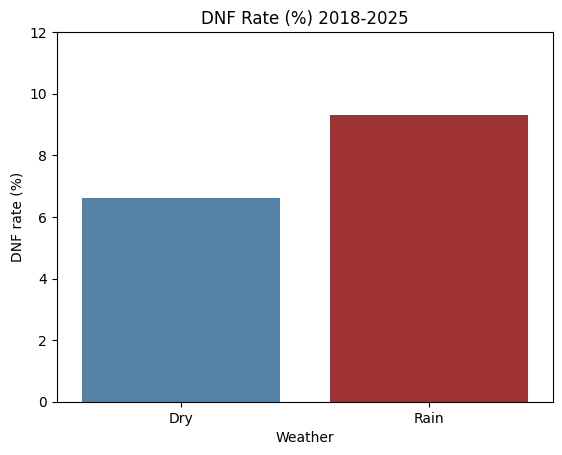

In [39]:
# 1) races per weather type
race_counts = f1_data.groupby('rained')['driver_dnf'].count()

# 2) total DNFs per weather type
dnf_counts  = f1_data.groupby('rained')['driver_dnf'].sum()

# 3) DNF rate
rate = (dnf_counts / race_counts * 100).reset_index(name='dnf_rate')

# 4) plot

sns.barplot(
    data=rate,
    x='rained',
    y='dnf_rate',
    palette={'0': 'steelblue', '1': 'firebrick'}
)
plt.xticks([0, 1], labels=['Dry', 'Rain'])
plt.title('DNF Rate (%) 2018-2025')
plt.xlabel('Weather')
plt.ylabel('DNF rate (%)')
plt.ylim(0, 12)
plt.show()

When it rains, dnf rate jump by nearly 30%

In [ ]:
f1_data['weather'] = f1_data['rained'].map({0: 'Dry', 1: 'Rain'})

# Plot with standard deviation error bars
plt.figure(figsize=(23, 8))
sns.barplot(
    data=f1_data,
    x='driver',
    y='finish',
    hue='weather',
    palette={'Dry': 'steelblue', 'Rain': 'firebrick'},
    ci='sd'  # Add standard deviation error bars
)

plt.title('Average Finish by Driver and Weather Condition (with Std Dev)')
plt.xlabel('Driver')
plt.ylabel('Average Position')
plt.legend(title='Weather')
plt.tight_layout()
plt.xticks(fontsize=14)
plt.show()

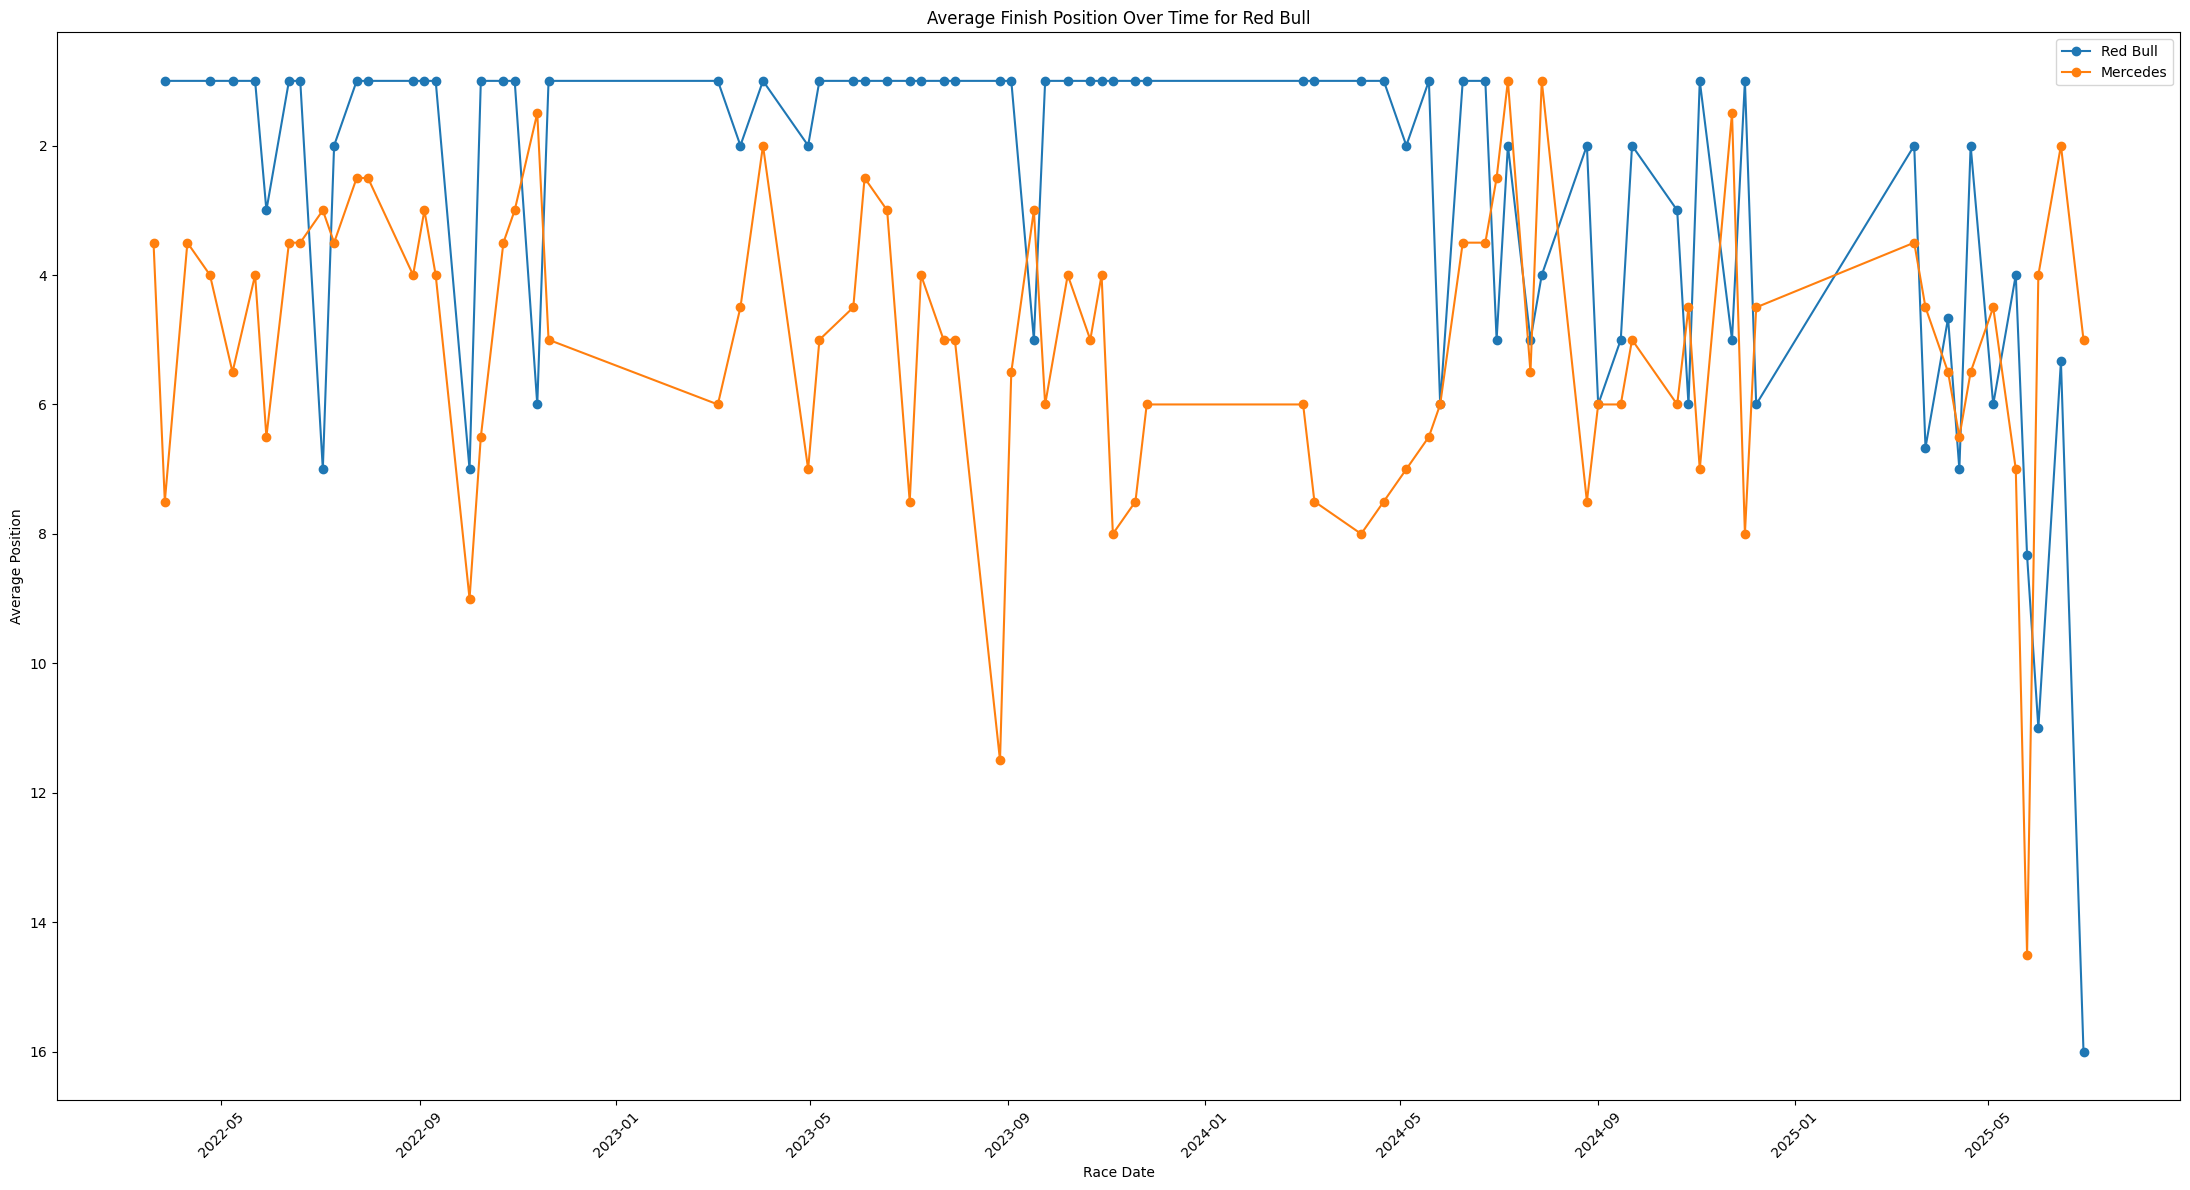

In [71]:
finished_data = f1_data[(f1_data['team_dnf'] == 0)&(f1_data['driver_dnf'] == 0)&(f1_data['year']>=2022)]

# Then filter for the two teams
teams_of_interest = ['Red Bull', 'Mercedes']
team_data = finished_data[finished_data['team'].isin(teams_of_interest)]

# Group by date and calculate average finish position
avg_position_by_date = (
    team_data.groupby(['team', 'date'])['finish']
    .mean()
    .reset_index()
    .sort_values(by='date')
)

# Plot the line graph
plt.figure(figsize=(22, 12))
for team in teams_of_interest:
    team_subset = avg_position_by_date[avg_position_by_date['team'] == team]
    plt.plot(
        team_subset['date'],
        team_subset['finish'],
        marker='o',
        linestyle='-',
        label=team
    )

plt.title('Average Finish Position Over Time for Red Bull')
plt.xlabel('Race Date')
plt.ylabel('Average Position')
plt.gca().invert_yaxis()  # P1 at the top
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
